Imports
-

In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,auc,classification_report,RocCurveDisplay

Data formatting
-

In [89]:
#read and inspect data
df= pd.read_csv("data.csv",index_col=0)
print(df.head())

   location  country  gender   age  vis_wuhan  from_wuhan  symptom1  symptom2  \
0       104        8       1  66.0          1           0        14        31   
1       101        8       0  56.0          0           1        14        31   
2       137        8       1  46.0          0           1        14        31   
3       116        8       0  60.0          1           0        14        31   
4       116        8       1  58.0          0           0        14        31   

   symptom3  symptom4  symptom5  symptom6  diff_sym_hos  result  
0        19        12         3         1             8       1  
1        19        12         3         1             0       0  
2        19        12         3         1            13       0  
3        19        12         3         1             0       0  
4        19        12         3         1             0       0  


In [90]:
data_length=len(df)
print(data_length)

863


In [91]:
X=df.drop("result",axis=1)
print(X.head())

   location  country  gender   age  vis_wuhan  from_wuhan  symptom1  symptom2  \
0       104        8       1  66.0          1           0        14        31   
1       101        8       0  56.0          0           1        14        31   
2       137        8       1  46.0          0           1        14        31   
3       116        8       0  60.0          1           0        14        31   
4       116        8       1  58.0          0           0        14        31   

   symptom3  symptom4  symptom5  symptom6  diff_sym_hos  
0        19        12         3         1             8  
1        19        12         3         1             0  
2        19        12         3         1            13  
3        19        12         3         1             0  
4        19        12         3         1             0  


In [92]:
y=df['result']
print(y.head())

0    1
1    0
2    0
3    0
4    0
Name: result, dtype: int64


In [93]:
#split data into 0.2 test data,0.2 validation data,0.6 train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1) # 0.25 x 0.8 = 0.2

KNN MODEL
-

In [94]:
#fit the data
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier()
KNN.fit(X_train,y_train)

KNeighborsClassifier()

In [95]:
#predict the data
y_val_predict_knn=KNN.predict(X_val)
print(y_val_predict_knn)

[0 0 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0]


In [97]:
print ("KNN Metrics")
print(classification_report(y_val,y_val_predict_knn))
print('\n')
print(confusion_matrix(y_val,y_val_predict_knn))

KNN Metrics
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       149
           1       0.88      0.58      0.70        24

    accuracy                           0.93       173
   macro avg       0.91      0.78      0.83       173
weighted avg       0.93      0.93      0.92       173



[[147   2]
 [ 10  14]]


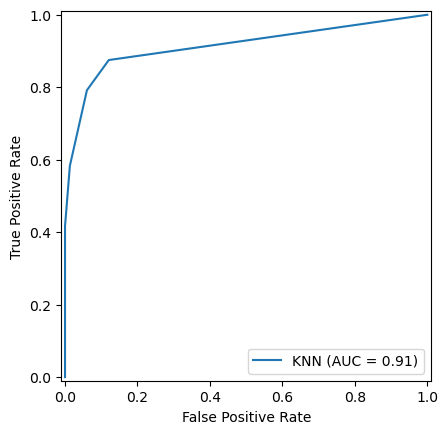

In [98]:
#extract probabilities of entry classification
y_proba_knn = KNN.predict_proba(X_val)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_val, y_proba_knn)
# Calculate auc
roc_auc_knn = auc(fpr_knn, tpr_knn)
#display
display_knn = RocCurveDisplay(fpr=fpr_knn, tpr=tpr_knn, roc_auc=roc_auc_knn,estimator_name='KNN')

display_knn.plot()
plt.show()

Hyperparameter Tuning of KNN model
-

In [99]:
#using Grid search
from sklearn.model_selection import GridSearchCV

param_grid_knn = {
    'n_neighbors': [1,3, 5, 7, 10],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Perform grid search
grid_search_knn = GridSearchCV(estimator=KNN, param_grid=param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search_knn.best_params_)
print("Best Cross-Validation Score:", grid_search_knn.best_score_)

# Use the best model for predictions
best_knn = grid_search_knn.best_estimator_
y_val_predict_best_knn = best_knn.predict(X_val)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best Cross-Validation Score: 0.9439507094846901


In [100]:
#display some metrics
print('KNN Metrics after tuning hyper parameters')
print(classification_report(y_val,y_val_predict_best_knn))
print('\nConfusion matrix')
print(confusion_matrix(y_val,y_val_predict_best_knn))

KNN Metrics after tuning hyper parameters
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       149
           1       0.84      0.67      0.74        24

    accuracy                           0.94       173
   macro avg       0.90      0.82      0.85       173
weighted avg       0.93      0.94      0.93       173


Confusion matrix
[[146   3]
 [  8  16]]


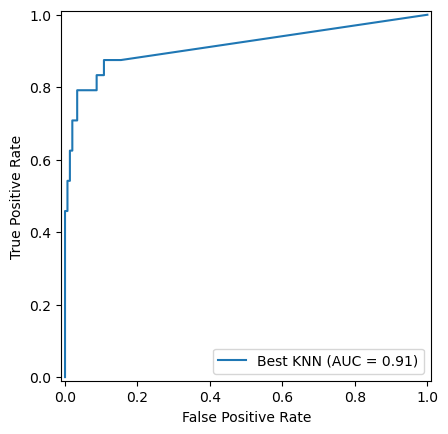

In [101]:
#extract probabilities of entry classification
y_proba_best_knn = best_knn.predict_proba(X_val)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_best_knn, tpr_best_knn, thresholds_best_knn = roc_curve(y_val, y_proba_best_knn)
# Calculate auc
roc_auc_best_knn = auc(fpr_best_knn, tpr_best_knn)
#display
display_best_knn = RocCurveDisplay(fpr=fpr_best_knn, tpr=tpr_best_knn, roc_auc=roc_auc_best_knn,estimator_name='Best KNN')

display_best_knn.plot()
plt.show()

Testing the data
-

In [102]:
y_test_predict_knn=best_knn.predict(X_test)
print(y_test_predict_knn)

[0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 0]


In [103]:
#display some metrics
print('KNN Metrics using test data')
print(classification_report(y_test,y_test_predict_knn))
print('\nConfusion matrix')
print(confusion_matrix(y_test,y_test_predict_knn))

KNN Metrics using test data
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       153
           1       0.72      0.65      0.68        20

    accuracy                           0.93       173
   macro avg       0.84      0.81      0.82       173
weighted avg       0.93      0.93      0.93       173


Confusion matrix
[[148   5]
 [  7  13]]


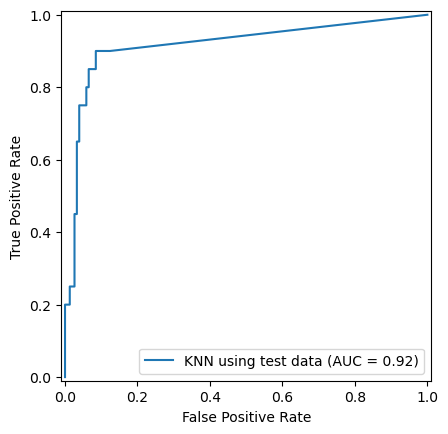

In [147]:
#extract probabilities of entry classification
y_proba_knn2 = best_knn.predict_proba(X_test)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_knn2, tpr_knn2, thresholds_knn2 = roc_curve(y_test, y_proba_knn2)
# Calculate auc
roc_auc_knn2 = auc(fpr_knn2, tpr_knn2)
#display
display_knn2 = RocCurveDisplay(fpr=fpr_knn2, tpr=tpr_knn2, roc_auc=roc_auc_knn2,estimator_name='KNN using test data')

display_knn2.plot()
plt.show()

Logistic regression Model
-

In [140]:
#fit the data
from sklearn.linear_model import LogisticRegression 
logReg=LogisticRegression(max_iter=800)
logReg.fit(X_train,y_train)

LogisticRegression(max_iter=800)

In [106]:
#predict the data
y_val_predict_logReg=logReg.predict(X_val)
print(y_val_predict_logReg)

[0 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


In [107]:
#display some metrics
print('logistic regression')
print(classification_report(y_val,y_val_predict_logReg))
print('\nConfusion matrix')
print(confusion_matrix(y_val,y_val_predict_logReg))

logistic regression
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       149
           1       0.76      0.67      0.71        24

    accuracy                           0.92       173
   macro avg       0.85      0.82      0.83       173
weighted avg       0.92      0.92      0.92       173


Confusion matrix
[[144   5]
 [  8  16]]


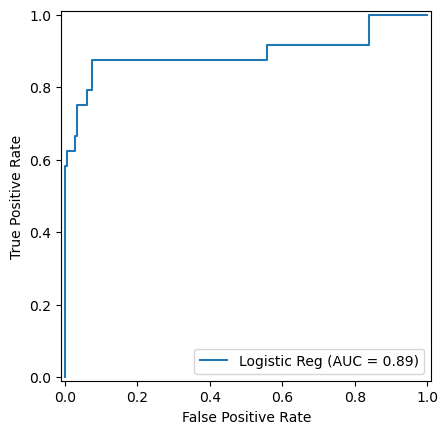

In [108]:
#extract probabilities of entry classification
y_proba_logReg = logReg.predict_proba(X_val)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_logReg, tpr_logReg, thresholds_logReg = roc_curve(y_val, y_proba_logReg)
# Calculate auc
roc_auc_logReg = auc(fpr_logReg, tpr_logReg)
#display
display_logReg = RocCurveDisplay(fpr=fpr_logReg, tpr=tpr_logReg, roc_auc=roc_auc_logReg, estimator_name='Logistic Reg')

display_logReg.plot()
plt.show()

Hyperparameter Tuning of Logistic Regression model
-

In [146]:
#using Grid search
from sklearn.model_selection import GridSearchCV

param_grid_logReg = {
    'C': [0.01, 0.1, 1, 10, 100],  
    'penalty': ['l1', 'l2', 'elasticnet'],  
    'solver': ['liblinear', 'saga'],  
    'max_iter': [10,200,400,600,800,1000]  # Iterations for convergence
}
# Perform grid search
grid_search_logReg = GridSearchCV(estimator=logReg, param_grid=param_grid_logReg, cv=5, scoring='accuracy',n_jobs=-1)
grid_search_logReg.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search_logReg.best_params_)
print("Best Cross-Validation Score:", grid_search_logReg.best_score_)

# Use the best model for predictions
best_logReg = grid_search_logReg.best_estimator_
y_val_predict_best_logReg = best_logReg.predict(X_val)

Best Parameters: {'C': 10, 'max_iter': 200, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.9438946975354743


C:\Users\abdel\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
300 fits failed out of a total of 900.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\abdel\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\abdel\anaconda3\Lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\abdel\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1172, in fit
    solver 

In [110]:
#display some metrics
print('logistic regression Metrics after tuning hyper parameters')
print(classification_report(y_val,y_val_predict_best_logReg))
print('\nConfusion matrix')
print(confusion_matrix(y_val,y_val_predict_best_logReg))

logistic regression Metrics after tuning hyper parameters
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       149
           1       0.76      0.67      0.71        24

    accuracy                           0.92       173
   macro avg       0.85      0.82      0.83       173
weighted avg       0.92      0.92      0.92       173


Confusion matrix
[[144   5]
 [  8  16]]


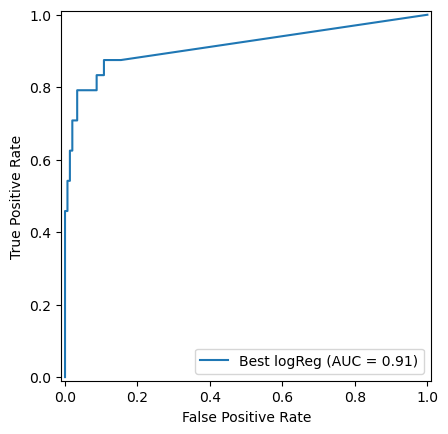

In [111]:
#extract probabilities of entry classification
y_proba_best_logReg = best_logReg.predict_proba(X_val)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_best_logReg, tpr_best_logReg, thresholds_best_logReg = roc_curve(y_val, y_proba_best_knn)
# Calculate auc
roc_auc_best_logReg = auc(fpr_best_logReg, tpr_best_logReg)
#display
display_best_logReg = RocCurveDisplay(fpr=fpr_best_logReg, tpr=tpr_best_logReg, roc_auc=roc_auc_best_logReg,estimator_name='Best logReg')

display_best_logReg.plot()
plt.show()

Testing the data
-

In [112]:
#predict the data
y_test_predict_logReg=best_logReg.predict(X_test)
print(y_test_predict_logReg)

[0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0]


In [113]:
#display some metrics
print('logistic regression Metrics using test data')
print(classification_report(y_test,y_test_predict_logReg))
print('\nConfusion matrix')
print(confusion_matrix(y_test,y_test_predict_logReg))

logistic regression Metrics using test data
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       153
           1       0.80      0.60      0.69        20

    accuracy                           0.94       173
   macro avg       0.87      0.79      0.83       173
weighted avg       0.93      0.94      0.93       173


Confusion matrix
[[150   3]
 [  8  12]]


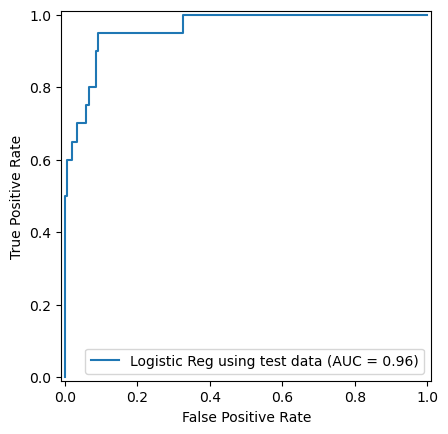

In [114]:
#extract probabilities of entry classification
y_proba_logReg2 = logReg.predict_proba(X_test)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_logReg2, tpr_logReg2, thresholds_logReg2 = roc_curve(y_test, y_proba_logReg2)
# Calculate auc
roc_auc_logReg2 = auc(fpr_logReg2, tpr_logReg2)
#display
display_logReg2 = RocCurveDisplay(fpr=fpr_logReg2, tpr=tpr_logReg2, roc_auc=roc_auc_logReg2, estimator_name='Logistic Reg using test data')

display_logReg2.plot()
plt.show()

Gaussian Naive Bayes (GaussianNB) Model
-

In [115]:
#fit the data
from sklearn.naive_bayes import GaussianNB
NaiveBayes= GaussianNB()
NaiveBayes.fit(X_train,y_train)

GaussianNB()

In [116]:
#predict the data
y_val_predict_NB=NaiveBayes.predict(X_val)
print(y_val_predict_NB)

[0 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0
 1 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 1 0 1 1 0 1 0 0
 1 0 0 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 1 1]


In [117]:
#display some metrics
print('Naive bayes Metrics')
print(classification_report(y_val,y_val_predict_NB))
print('\nConfusion matrix')
print(confusion_matrix(y_val,y_val_predict_NB))

Naive bayes Metrics
              precision    recall  f1-score   support

           0       0.97      0.77      0.85       149
           1       0.36      0.83      0.51        24

    accuracy                           0.77       173
   macro avg       0.66      0.80      0.68       173
weighted avg       0.88      0.77      0.81       173


Confusion matrix
[[114  35]
 [  4  20]]


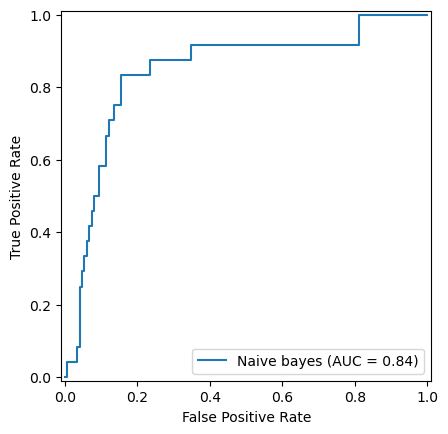

In [118]:
#extract probabilities of entry classification
y_proba_NB = NaiveBayes.predict_proba(X_val)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_NB, tpr_NB, thresholds_NB = roc_curve(y_val, y_proba_NB)
# Calculate auc
roc_auc_NB = auc(fpr_NB, tpr_NB)
#display
display_NB = RocCurveDisplay(fpr=fpr_NB, tpr=tpr_NB, roc_auc=roc_auc_NB,estimator_name='Naive bayes')

display_NB.plot()
plt.show()

In [119]:
#using Grid search
from sklearn.model_selection import GridSearchCV

param_grid_NB = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

# Perform grid search
grid_search_NB = GridSearchCV(estimator=NaiveBayes, param_grid=param_grid_NB, cv=5, scoring='accuracy')
grid_search_NB.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search_NB.best_params_)
print("Best Cross-Validation Score:", grid_search_NB.best_score_)

# Use the best model for predictions
best_NB = grid_search_NB.best_estimator_
y_val_predict_best_NB = best_NB.predict(X_val)

Best Parameters: {'var_smoothing': 1e-06}
Best Cross-Validation Score: 0.8627893950709484


In [120]:
#display some metrics
print('Naive bayes Metrics after tuning hyper parameters')
print(classification_report(y_val,y_val_predict_best_NB))
print('\nConfusion matrix')
print(confusion_matrix(y_val,y_val_predict_best_NB))

Naive bayes Metrics after tuning hyper parameters
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       149
           1       0.50      0.58      0.54        24

    accuracy                           0.86       173
   macro avg       0.72      0.74      0.73       173
weighted avg       0.87      0.86      0.87       173


Confusion matrix
[[135  14]
 [ 10  14]]


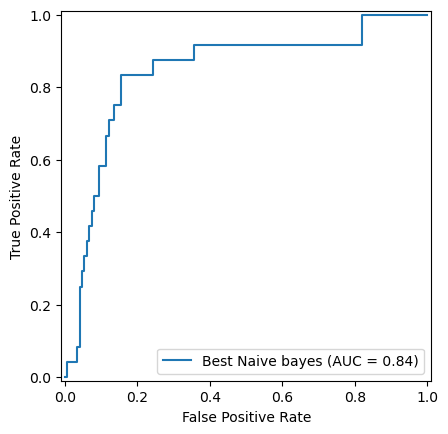

In [121]:
#extract probabilities of entry classification
y_proba_best_NB = best_NB.predict_proba(X_val)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_best_NB, tpr_best_NB, thresholds_best_NB = roc_curve(y_val, y_proba_best_NB)
# Calculate auc
roc_auc_best_NB = auc(fpr_best_NB, tpr_best_NB)
#display
display_best_NB = RocCurveDisplay(fpr=fpr_best_NB, tpr=tpr_best_NB, roc_auc=roc_auc_best_NB,estimator_name='Best Naive bayes')

display_best_NB.plot()
plt.show()

Testing the data
-

In [122]:
#predict the data
y_test_predict_NB=best_NB.predict(X_test)
print(y_test_predict_NB)

[0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0
 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0]


In [123]:
#display some metrics
print('Naive bayes Metrics using test data')
print(classification_report(y_test,y_test_predict_NB))
print('\nConfusion matrix')
print(confusion_matrix(y_test,y_test_predict_NB))

Naive bayes Metrics using test data
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       153
           1       0.43      0.60      0.50        20

    accuracy                           0.86       173
   macro avg       0.69      0.75      0.71       173
weighted avg       0.89      0.86      0.87       173


Confusion matrix
[[137  16]
 [  8  12]]


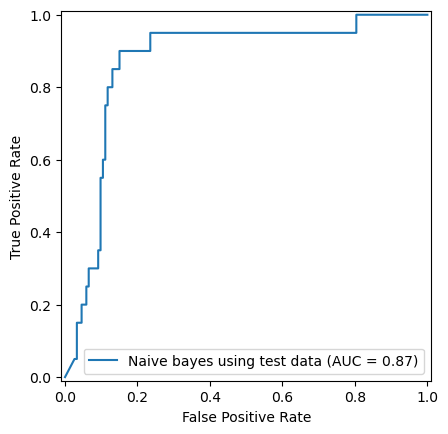

In [124]:
#extract probabilities of entry classification
y_proba_NB2 = NaiveBayes.predict_proba(X_test)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_NB2, tpr_NB2, thresholds_NB2 = roc_curve(y_test, y_proba_NB2)
# Calculate auc
roc_auc_NB2 = auc(fpr_NB2, tpr_NB2)
#display
display_NB2 = RocCurveDisplay(fpr=fpr_NB2, tpr=tpr_NB2, roc_auc=roc_auc_NB2,estimator_name='Naive bayes using test data')

display_NB2.plot()
plt.show()